在强化学习中，特别是在处理连续动作空间时，经常使用 tanh 函数将动作值限制在 [−1,1] 范围内。
- 然而，这种变换会改变动作的概率分布，因此需要调整对数概率密度以反映这种变化。


In [ ]:
# 调整对数概率密度以适应 tanh 变换
log_prob = log_prob - torch.log(1 - torch.tanh(action).pow(2) + 1e-7)

- torch.tanh：对动作 action 应用 tanh 函数，将动作值限制在 [−1,1] 范围内。
- pow(2)：计算 tanh(action) 的平方。
    - 作用：计算 $tanh^{2}(action)$，这是调整对数概率密度的关键部分。
- 计算 $tanh^{2}(action)$
    - 作用：根据 tanh 函数的性质，$tanh^{2}(action)$ 等于 $sech^{2}(x)$，
    - 即 tanh 函数的导数。这一步是为了调整对数概率密度，以反映 tanh 变换对概率分布的影响。
- 1e-7：添加一个小的常数（如 1e−7）以避免对零取对数，确保数值稳定性。
    - 作用：计算调整项，用于修正对数概率密度。
- log_prob - torch.log(1 - torch.tanh(action).pow(2) + 1e-7)
    - 从原始对数概率密度中减去调整项
    - 作用：调整对数概率密度，以适应 tanh 变换。
    - <font color='red'>这一步确保了在应用 tanh 变换后，对数概率密度仍然正确反映动作的概率。<font>

In [1]:
from  IPython.display import Image

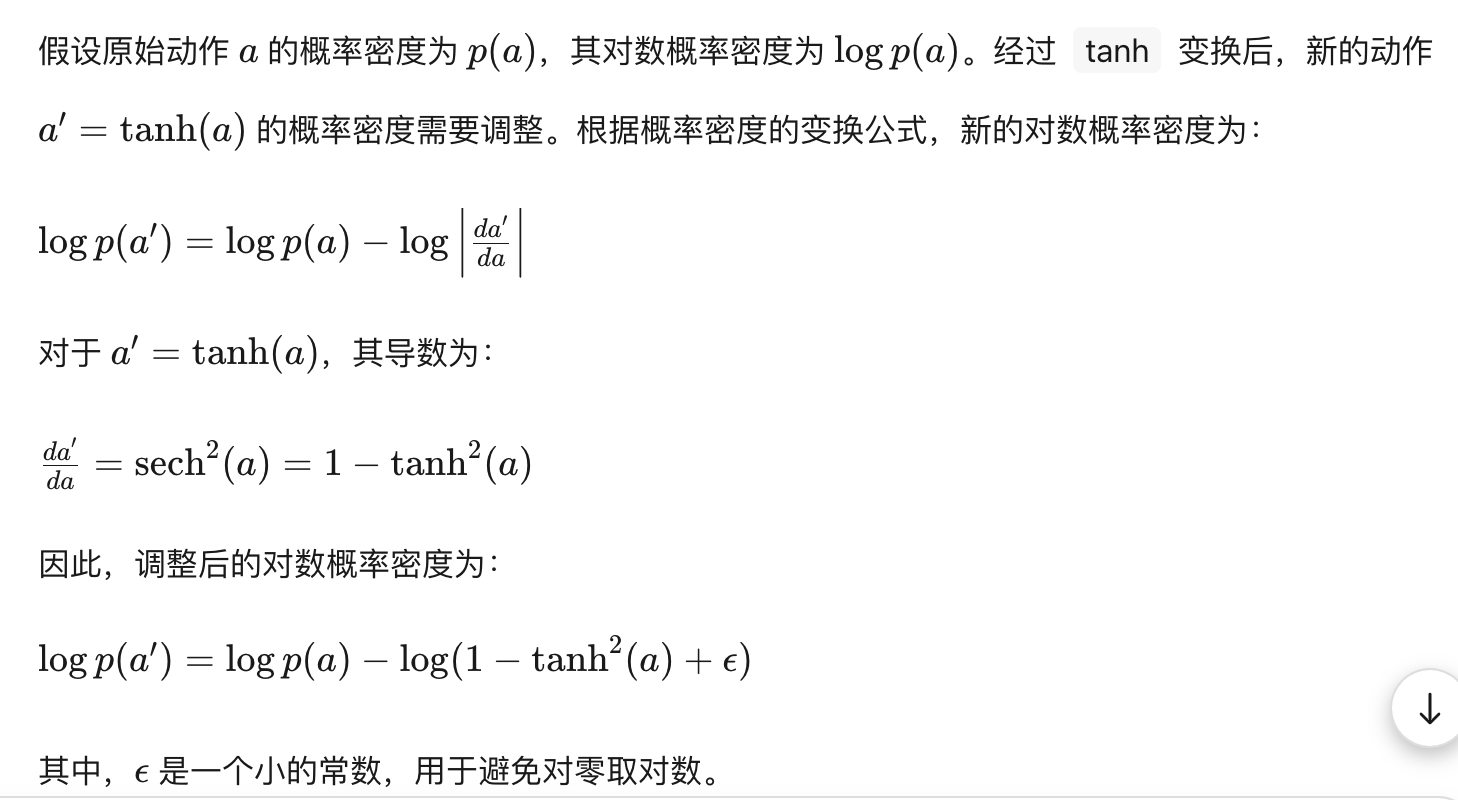

In [3]:
Image(filename='./image/math_log.png',width=600)

In [5]:
import torch

# 假设动作和对数概率密度
action = torch.tensor([0.5, -0.3, 0.8], dtype=torch.float32)
log_prob = torch.tensor([0.1, 0.2, 0.3], dtype=torch.float32)

print("原来的log_prob:",log_prob)

# 调整对数概率密度以适应 tanh 变换
log_prob = log_prob - torch.log(1 - torch.tanh(action).pow(2) + 1e-7)


print("调整后的 log_prob:", log_prob)

原来的log_prob: tensor([0.1000, 0.2000, 0.3000])
调整后的 log_prob: tensor([0.3402, 0.2887, 0.8815])
